# AG-HYPOPT · Trial 21

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Twenty trials are registered; cell 2 reports `phase = trials` (20/5), so proposals carry expected-improvement (ei) values. **Best = trial_08** (objective 0.1099). Picture (mu travel = `lr_mu*(1 - mu_anneal/2)`):

- **trial_08 (0.1099, best):** travel 0.134.
- optimum cluster (0 div): trial_15 0.1103 (0.127), trial_16 0.1112 (0.128), trial_12 0.1115 (0.128), trial_18 0.1121 (0.138), trial_09 = trial_20 0.1126 (0.123 / 0.144), trial_01 = trial_14 0.1127 (0.120 / 0.140), trial_13 0.1132 (0.134), trial_05 = trial_19 0.1135 (0.088 / 0.125).
- lower travel / worse: trial_07 0.1140 (0.097), trial_06 0.1188 (0.082).
- diverging: trial_17 0.1329 (0.088), trial_10 0.1975 (0.099), trial_03 0.1362 (0.074), trial_04 0.1418 (0.074), trial_02 0.1449 (0.264).

State of play: sixteen divergence-free runs now inhabit a flat optimum at travel ~0.13 (nearly all within 0.1099-0.1135); the low-travel region (<0.10) is slightly worse and remains the source of every sporadic divergence. Residual errors unchanged everywhere: mid-T mu overshoot, 3nW high-T mu undershoot, low-T gamma under-recovery. Objective = T-weighted (w=0.25+0.75*T/100) mean of capped rel-sq errors over the 8-experiment benchmark.

In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_21'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 40    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (20/5 trials)
ID |     ei | params
 1 | 3.7435 | {"gamma_anneal": 0.5009138182937567, "lr_gamma": 0.4728735105783793, "lr_mu": 0.14530961651521382, "mu_anneal": 0.34108997949256514}
 2 | 3.7380 | {"gamma_anneal": 0.49857516718316186, "lr_gamma": 0.47234443212119914, "lr_mu": 0.13759227715874703, "mu_anneal": 0.3551907773616118}
 3 | 3.7192 | {"gamma_anneal": 0.4791231439664532, "lr_gamma": 0.4933097109516249, "lr_mu": 0.1640304105081821, "mu_anneal": 0.34753589215009817}
 4 | 3.9030 | {"gamma_anneal": 0.47227943878293116, "lr_gamma": 0.4716158160640441, "lr_mu": 0.16690567035774542, "mu_anneal": 0.34550376211493733}
 5 | 3.8656 | {"gamma_anneal": 0.48966358294509715, "lr_gamma": 0.4483679994086845, "lr_mu": 0.09840110540151517, "mu_anneal": 0.35099567831944495}
 6 | 3.5119 | {"gamma_anneal": 0.17337057027895067, "lr_gamma": 0.4879320058537451, "lr_mu": 0.1510425332011161, "mu_anneal": 0.3500309356637788}
 7 | 3.8285 | {"gamma_anneal": 0.5017746427630972, "lr_gamma": 0.4

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

Cell 2 is in the informed `trials` phase (20 trials). Candidate travel `lr_mu*(1 - mu_anneal/2)`, with ei:
- candidate 4: **ei 3.90** — `lr_mu=0.167`, `mu_anneal=0.346` (travel **0.138**), `lr_gamma=0.472`, `gamma_anneal=0.472`.
- candidate 8: ei 3.90 — `lr_mu=0.162`, `mu_anneal=0.351` (travel 0.134), `lr_gamma=0.141` (very low), `gamma_anneal=0.476`.
- candidate 5: ei 3.87 — `lr_mu=0.098`, `mu_anneal=0.351` (travel 0.081, low), `lr_gamma=0.448`.
- candidate 7: ei 3.83 — `lr_mu=0.142`, `mu_anneal=0.344` (travel 0.117), `lr_gamma=0.467`.
- candidate 1: ei 3.74 — `lr_mu=0.145`, `mu_anneal=0.341` (travel 0.120), `lr_gamma=0.473`.

Candidates 4 and 8 are tied at the top ei (3.90). Candidate 4 sits at travel 0.138 on the optimum with `lr_gamma=0.472`/`gamma_anneal=0.472` in the proven-safe range. Candidate 8 is also at the optimum travel (0.134) but with `lr_gamma=0.141`, a very low value well outside the safe band (all divergence-free runs had `lr_gamma` >= ~0.40) — an unnecessary, untested risk. Among the remaining candidates, 5 is low-travel (0.081) and the rest are ordinary optimum resamples at slightly lower ei. So candidate 4 is the tied-top, best-supported, safe choice.

I choose candidate 4 (4 goes into the SET cell below).

In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 4            # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'gamma_anneal': 0.47227943878293116, 'lr_gamma': 0.4716158160640441, 'lr_mu': 0.16690567035774542, 'mu_anneal': 0.34550376211493733}
Running  1nW Trans05 ... 

μ 9.39 -> 11.01 | γ 8.5 -> 4.73 | NLL 1.27


Running  1nW Trans20 ... 

μ 17.32 -> 44.24 | γ 8.5 -> 6.24 | NLL 5.49


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 80.73 | γ 14.1 -> 14.76 | NLL 3.69


Running 3nW Trans100 ... 

μ 175.71 -> 111.03 | γ 14.1 -> 14.38 | NLL 3.55



Total: 8.2 min


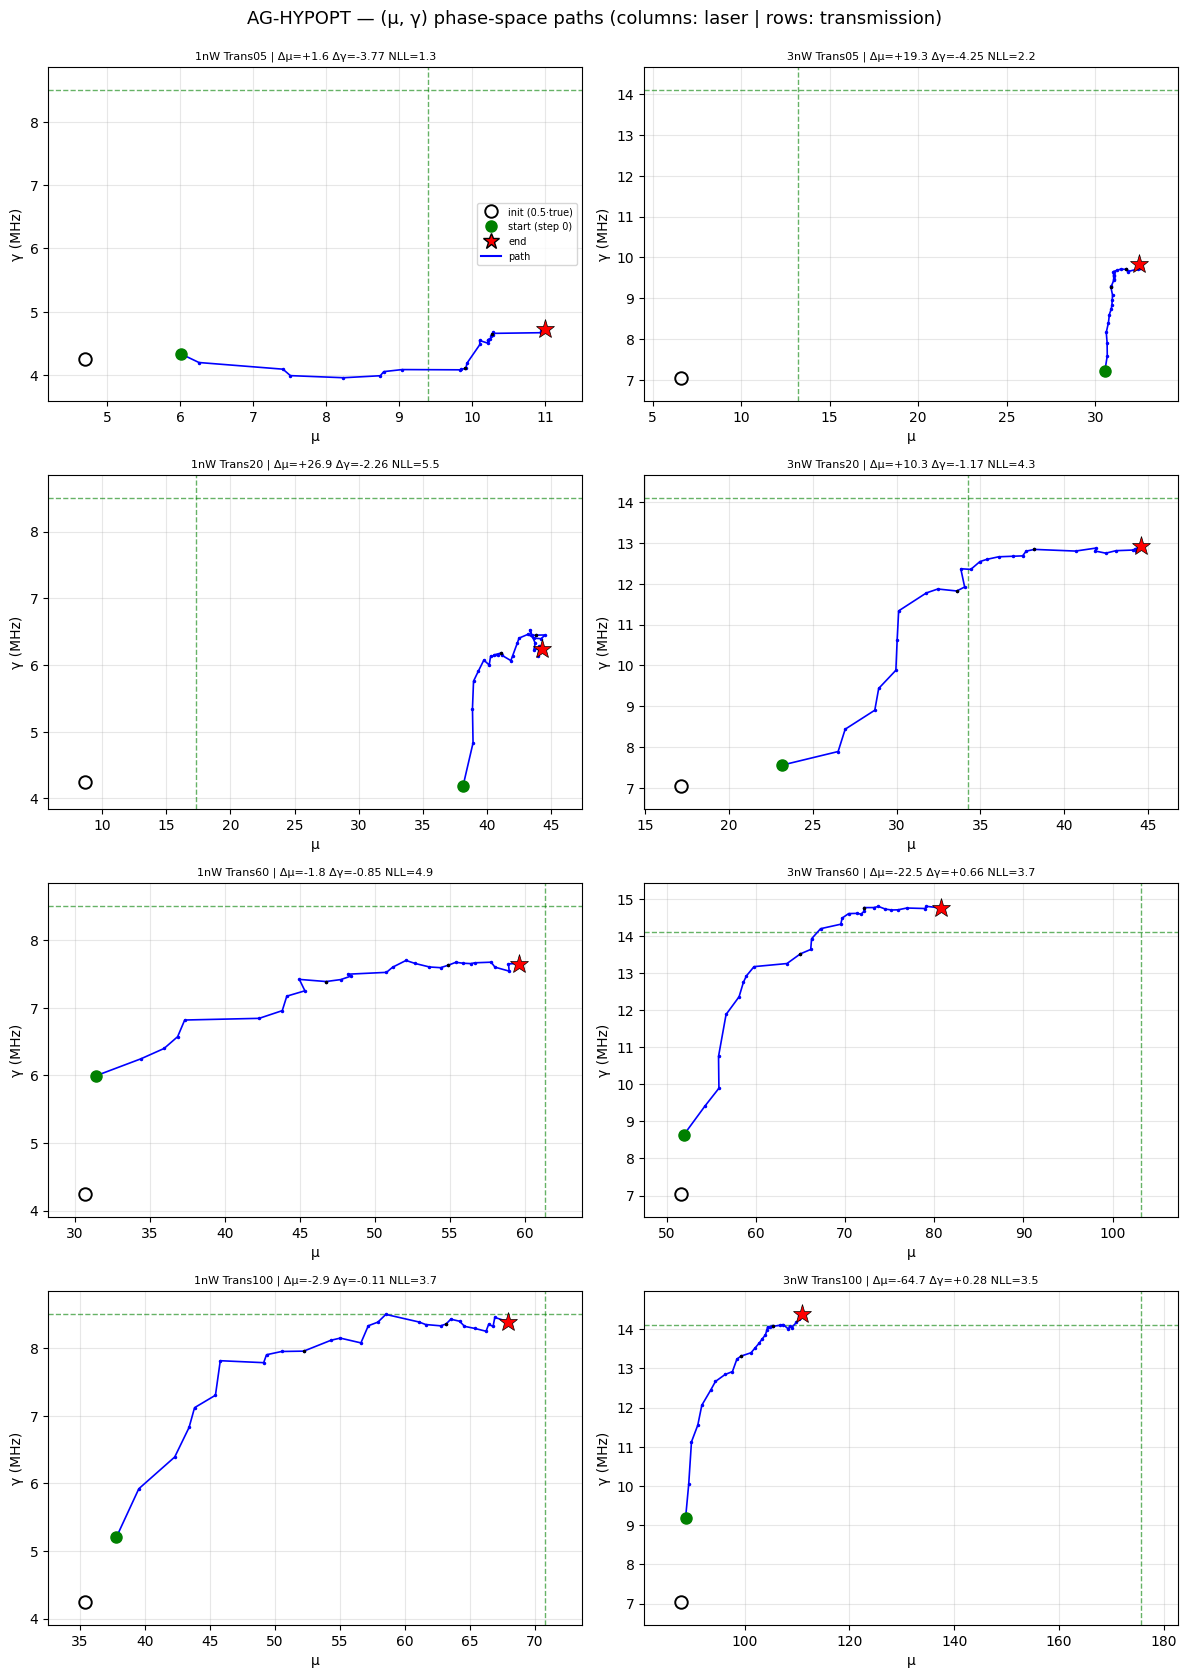

trial finished in 8.3 min
objective = 0.1074 ± 0.0825
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39   11.01   +17.2 |     8.50    4.73   -44.3
1nW Trans20       17.32   44.24  +155.5 |     8.50    6.24   -26.5
1nW Trans60       61.37   59.62    -2.9 |     8.50    7.65   -10.0
1nW Trans100       70.82   67.92    -4.1 |     8.50    8.39    -1.3
3nW Trans05       13.20   32.48  +146.0 |    14.10    9.85   -30.1
3nW Trans20       34.28   44.60   +30.1 |    14.10   12.93    -8.3
3nW Trans60      103.20   80.73   -21.8 |    14.10   14.76    +4.6
3nW Trans100      175.71  111.03   -36.8 |    14.10   14.38    +2.0

weighted objective (T-graded, cap=1.0) = 0.1074 | diverged cells: 0
μ: RMSE 27.170 (rel 77.9%, bias -4.208) | γ: RMSE 2.234 (rel 21.7%, bias -1.432)


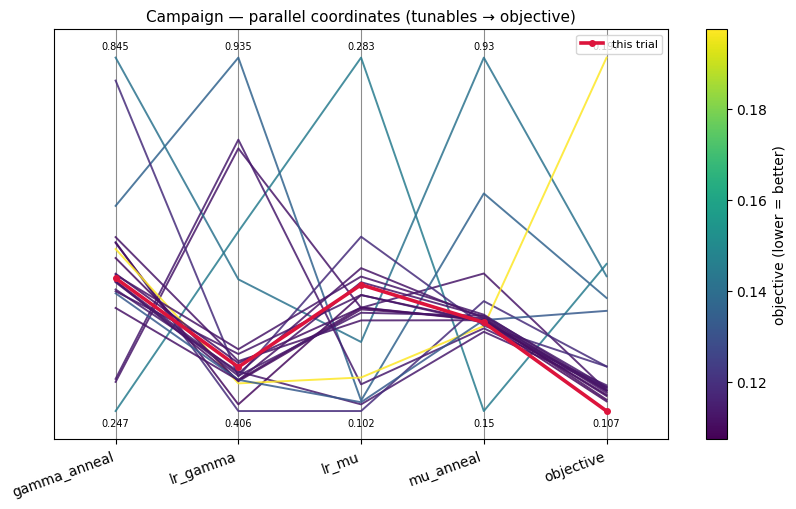

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 21 ran candidate 4 (ei=3.90, tied for top; chosen over the tied candidate 8 because the latter's `lr_gamma=0.141` is far outside the proven-safe band). Config: `lr_mu=0.1669`, `mu_anneal=0.3455` (effective mu travel 0.138), `lr_gamma=0.4716`, `gamma_anneal=0.4723`. It completed in 8.3 min with objective **0.1074 +/- 0.0825** and **0 diverged cells** — a **new campaign best**, beating trial_08 (0.1099). Ranking: **trial_21 0.1074** < trial_08 0.1099 < trial_15 0.1103 < trial_16 0.1112 < trial_12 0.1115 < trial_18 0.1121 < trial_09 = trial_20 0.1126 < ...

Aggregate accuracy: **mu rel-RMSE 77.9%** (RMSE 27.17, bias -4.21); **gamma rel-RMSE 21.7%** (RMSE 2.23, bias -1.43).

Per-cell relative errors:
- **mu:** 1nW T05 +17.2%, T20 +155.5%, T60 -2.9%, T100 -4.1% | 3nW T05 +146.0%, T20 +30.1%, T60 -21.8%, T100 -36.8%.
- **gamma:** 1nW T05 -44.3%, T20 -26.5%, T60 -10.0%, T100 -1.3% | 3nW T05 -30.1%, T20 -8.3%, T60 +4.6%, T100 +2.0%.

A new best after a long plateau. This sits at the same optimum mu travel as trial_08/18 (0.138) but with a *balanced* gamma schedule (`lr_gamma=0.4716`, `gamma_anneal=0.4723`, almost equal), and it edges trial_08 by 0.0025 by being mildly better across several cells simultaneously: 3nW T20 mu improved to +30.1%, gamma was solid at high T (1nW T100 -1.3%), and no diverged cell. So the plateau is not perfectly flat after all — a mid-range, balanced gamma schedule is marginally favourable. This is the first improvement in thirteen trials; it resets the campaign best to 0.1074 at travel 0.138 with `lr_gamma≈gamma_anneal≈0.47`.

**Summary:** Trial 21 (lr_mu=0.1669, mu_anneal=0.3455, lr_gamma=0.4716, gamma_anneal=0.4723): objective 0.1074 +/- 0.0825 with 0 diverged cells - a new campaign best, beating trial_08 (0.1099); the optimum travel (0.138) with a balanced gamma schedule gave small but real gains across cells.
**Key insight:** At the optimum, a balanced gamma schedule (`lr_gamma=0.472`, `gamma_anneal=0.472`, nearly equal) edged past trial_08 by 0.0025, showing the plateau is not perfectly flat and that a mid-range gamma balance is marginally favourable.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
**Notes for Anuar (not acted on).** The new best still shares the same residual pattern (mid-T mu overshoot ~+146-156%, 3nW high-T mu undershoot ~-22% / -37%, low-T gamma under-recovery ~-30% / -44%), so the gain came from a marginal, broad improvement rather than removing any single residual. This is the first new best since trial_08 and suggests a bit more exploration around travel 0.138 with balanced gamma may still help. Recorded only, not acted on.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = "Trial 21 (lr_mu=0.1669, mu_anneal=0.3455, lr_gamma=0.4716, gamma_anneal=0.4723): objective 0.1074 +/- 0.0825 with 0 diverged cells - a new campaign best, beating trial_08 (0.1099); the optimum travel (0.138) with a balanced gamma schedule gave small but real gains across cells"      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = "At the optimum, a balanced gamma schedule (lr_gamma=0.472, gamma_anneal=0.472, nearly equal) edged past trial_08 by 0.0025, showing the plateau is not perfectly flat and that a mid-range gamma balance is marginally favourable"  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_21 | current best: trial_21


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_22.ipynb. Open it and follow its cells from the top.
